## 1. Setup

### 1.0 Google Drive Sync
Pode ignorar essa seção se não estiver usando Google Colab

In [430]:
# Adicionar o conteúdo do drive no caminho do sistema

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

In [431]:
# modificar para o diretorio que contem a pasta do repositorio ao rodar esse notebook
# fazemos isso para ele conseguir ler a pasta /datasets que precisa estar dentro do diretório que contem esse notebook
%cd /content/drive/MyDrive/projetos-if702/projeto-churn/

!dir

[Errno 2] No such file or directory: '/content/drive/MyDrive/projetos-if702/projeto-churn/'
/Users/thomaz/Documents/CIn-UFPE/2026.1/projetos-if702/projeto-churn
zsh:1: command not found: dir


In [432]:
import sys

# Colocar o caminho exato da pasta onde está a pasta referente ao repositório do projeto
# O caminho base é sempre '/content/drive/MyDrive/' se criar um atalho no "Meu Drive" para a pasta sincronizada
caminho_projeto = '/content/drive/MyDrive/projetos-if702/projeto-churn'

# Adiciona a pasta no path do Python, caso ainda não esteja lá
if caminho_projeto not in sys.path:
    sys.path.append(caminho_projeto)

In [433]:

# Fazer recarregamento dos modulos locais.
# Assim não precisa reiniciar o kernel do colab toda vez que modificar alguma coisa nos arquivos .py

import importlib
sys.modules['imp'] = importlib

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1.1 Importar Libs

In [434]:
import importlib
import ml_utils
import churn_preprocessing

importlib.invalidate_caches()
importlib.reload(ml_utils)
importlib.reload(churn_preprocessing)

<module 'churn_preprocessing' from '/Users/thomaz/Documents/CIn-UFPE/2026.1/projetos-if702/projeto-churn/churn_preprocessing.py'>

In [435]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import optuna.visualization as optuna_vis
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import os
import torch
import json
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,)
from sklearn.model_selection import train_test_split
from scikitplot.metrics import plot_ks_statistic
from joblib import dump, load
import warnings
warnings.filterwarnings('ignore')

# Importar funções dos módulos customizados
from ml_utils import (
    train_model, evaluate_model, ks_test,
    build_hyperparameter_space, print_hyperparameter_space,
    run_optuna_search, get_loss_fn,
    DEFAULT_SCORING_METRIC, AVAILABLE_METRICS_SEARCH, AVAILABLE_LOSSES,
    RANDOM_STATE_MODEL, RANDOM_STATE_SAMPLE,
 )

from churn_preprocessing import load_split_datasets, get_X_y_from_split, OUTPUT_PREFIX, TARGET_COL

# Configurações de plotagem
plt.rcParams['figure.figsize'] = [12, 8]
sns.set_style("whitegrid")

print("Bibliotecas importadas com sucesso!")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

## CPU ou GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device.type.upper())

Bibliotecas importadas com sucesso!
Pandas: 3.0.3
NumPy: 2.4.6
Scikit-learn: 1.8.0
Device: CPU


### 1.2 Configuração do Modelo

In [436]:
# Configuração do modelo e hiperparâmetros
MODEL_NAME = "MLP"
MODEL_CLASS = MLPClassifier


# Configuração da busca de hiperparâmetros

module_name = getattr(MODEL_CLASS, "__module__", "")
print(f"Modelo configurado: {MODEL_NAME}")
print(module_name)

print("Hiperparâmetros disponíveis na classe do modelo:")
for param in MODEL_CLASS().get_params().keys():
    print(f"  - {param}")

Modelo configurado: MLP
sklearn.neural_network._multilayer_perceptron
Hiperparâmetros disponíveis na classe do modelo:
  - activation
  - alpha
  - batch_size
  - beta_1
  - beta_2
  - early_stopping
  - epsilon
  - hidden_layer_sizes
  - learning_rate
  - learning_rate_init
  - max_fun
  - max_iter
  - momentum
  - n_iter_no_change
  - nesterovs_momentum
  - power_t
  - random_state
  - shuffle
  - solver
  - tol
  - validation_fraction
  - verbose
  - warm_start


## 2. Carregamento dos Dados

In [437]:
# Carregamento e preparação inicial dos dados
print("=== CARREGAMENTO DOS DATASETS ===")

# Carregar e preparar datasets usando função do módulo
train_data, val_data, test_data = load_split_datasets(prefix=OUTPUT_PREFIX)
X_train, y_train, X_val, y_val, X_test, y_test = get_X_y_from_split(train_data, val_data, test_data, TARGET_COL)

# Manter nomes usados no restante do notebook
X_train_scaled = X_train
X_val_scaled = X_val
X_test_scaled = X_test

print(f"Dataset de treino: {train_data.shape}")
print(f"Dataset de validação: {val_data.shape}")
print(f"Dataset de teste: {test_data.shape}")
print(f"Features: {X_train_scaled.shape[1]}")

print("\nDistribuição das classes:")
print("Treino:", pd.Series(y_train).value_counts().to_dict())
print("Val:", pd.Series(y_val).value_counts().to_dict())
print("Teste:", pd.Series(y_test).value_counts().to_dict())


=== CARREGAMENTO DOS DATASETS ===
Dataset de treino: (5174, 20)
Dataset de validação: (2586, 20)
Dataset de teste: (1762, 20)
Features: 19

Distribuição das classes:
Treino: {0: 2587, 1: 2587}
Val: {0: 1293, 1: 1293}
Teste: {0: 1294, 1: 468}


In [438]:
print("\nPrimeiras linhas do dataset de treino:")
train_data.head()


Primeiras linhas do dataset de treino:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,PaperlessBilling_Yes,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,Churn
0,0.0,-0.181818,0.660499,0.051516,0.0,0.0,1.0,1.0,1.0,2.0,1.0,0.0,2.0,2.0,0.0,2.0,2.0,1.0,1.0,0
1,0.0,0.886364,-0.552846,0.591772,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,2.0,2.0,0.0,0.0,2.0,1.0,2.0,0
2,0.0,0.681818,-0.318475,0.662118,1.0,1.0,1.0,1.0,0.0,0.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,2.0,1.0,0
3,0.0,-0.363636,0.239978,-0.249371,1.0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,2.0,0.0,2.0,0.0,0.0,0.0,2.0,1
4,1.0,-0.068182,0.086347,0.092913,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,1


## 3. Busca de Hiperparâmetros

### 3.0 Sampling Para Busca
Pode escolher não usar também (ou usar frac=1.0)

In [ ]:

SAMPLE_SIZE = 0.05  # % of training data for hyperparameter search
# Amostra estratificada do dataset de treino
_, X_sample, _, y_sample = train_test_split(
    X_train_scaled, y_train,
    test_size=SAMPLE_SIZE,
    stratify=y_train,
    random_state=RANDOM_STATE_SAMPLE
)

print(f"Dataset original de treino: {X_train_scaled.shape[0]:,} amostras")
print(f"Amostra para busca de hiperparâmetros: {X_sample.shape[0]:,} amostras")
print(f"Redução: {(1 - X_sample.shape[0]/X_train_scaled.shape[0])*100:.1f}%")

print("\nDistribuição das classes na amostra:")
print("Amostra:", pd.Series(y_sample).value_counts().to_dict())
print("Original:", pd.Series(y_train).value_counts().to_dict())


### 3.1 Configs da Busca Optuna

In [440]:
print("Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra:", DEFAULT_SCORING_METRIC)
print("Métricas disponíveis para a busca de hiperparâmetros:\n", AVAILABLE_METRICS_SEARCH)
print("Funções de perda disponíveis para modelos PyTorch:\n", AVAILABLE_LOSSES)

Métrica padrão de avaliação na busca de hiperparâmetros caso não especificada outra: ks
Métricas disponíveis para a busca de hiperparâmetros:
 ['accuracy', 'precision', 'recall', 'f1', 'val_loss', 'auroc', 'ks']
Funções de perda disponíveis para modelos PyTorch:
 ['cross_entropy', 'bce_with_logits', 'mse']


In [441]:
# Optuna
n_trials = 150
scoring_metric = 'ks'
loss_fn = get_loss_fn('cross_entropy')

# modelos PyTorch somente
early_stopping_patience = 10
early_stopping_delta = 0.001
training_epochs_per_trial = 10

### 3.2 Definção do Espaço de Hiperparâmetros


In [442]:
hidden_layer_sizes = [
    (128, 64),
    (256, 64),
    (256, 128),
    (512, 128),
    (512, 256),
    (256, 128, 64),
    (512, 128, 64),
    (512, 256, 64),
    (512, 256, 128),
]

param_space = build_hyperparameter_space(
    MODEL_CLASS,
    overrides={
        "hidden_layer_sizes": {"type": "categorical", "values": hidden_layer_sizes},
        "alpha": {"type": "float", "values": [1e-5, 1.0, None, True]},
        "learning_rate_init": {"type": "float", "values": [1e-4, 5e-3, None, True]},
        "max_iter": {"type": "categorical", "values": [500]},
        "learning_rate": {"type": "categorical", "values": ["adaptive"]},
        "solver": {"type": "categorical", "values": ["adam"]},
        "batch_size": {"type": "categorical", "values": [128, 256, 512]},
        "activation": {"type": "categorical", "values": ["relu", "tanh"]},
        "early_stopping": {"type": "categorical", "values": [True]},
        "validation_fraction": {"type": "categorical", "values": [0.1]},
        "n_iter_no_change": {"type": "categorical", "values": [20]},
    },
)
print_hyperparameter_space(param_space)

Hyperparameter space:
- hidden_layer_sizes: type=categorical, values=[(128, 64), (256, 64), (256, 128), (512, 128), (512, 256), (256, 128, 64), (512, 128, 64), (512, 256, 64), (512, 256, 128)]
- alpha: type=float, args=[1e-05, 1.0], kwargs={'log': True}
- learning_rate_init: type=float, args=[0.0001, 0.005], kwargs={'log': True}
- max_iter: type=categorical, values=[500]
- learning_rate: type=categorical, values=['adaptive']
- solver: type=categorical, values=['adam']
- batch_size: type=categorical, values=[128, 256, 512]
- activation: type=categorical, values=['relu', 'tanh']
- early_stopping: type=categorical, values=[True]
- validation_fraction: type=categorical, values=[0.1]
- n_iter_no_change: type=categorical, values=[20]


### 3.3 Executar Busca de Hiperparâmetros

In [443]:

print(f"=== BUSCA DE HIPERPARÂMETROS - {MODEL_NAME} ===")
print(f"Iniciando busca de hiperparâmetros para {MODEL_NAME}...")
print(f"Trials: {n_trials}")
print(f"Usando amostra de {X_sample.shape[0]:,} exemplos\n")
print(f"Hiperparâmetros no espaço: {list(param_space.keys())}")

direction = "minimize" if scoring_metric in {"val_loss", "loss"} else "maximize"
study = run_optuna_search(
    model_class=MODEL_CLASS,
    space=param_space,
    X_train=X_sample,
    y_train=y_sample,
    X_val=X_val,
    y_val=y_val,
    n_trials=n_trials,
    direction=direction,
    scoring_metric=scoring_metric,
    device=device,
    epochs=training_epochs_per_trial,
    patience=early_stopping_patience,
    min_delta=early_stopping_delta,
    loss_fn=loss_fn,
 )

print(f"\n--- RESULTADOS {MODEL_NAME} ---")
print("Melhores hiperparâmetros encontrados:")
for param, value in study.best_params.items():
    print(f"  {param}: {value}")
print(f"\nMelhor score ({scoring_metric}): {study.best_value:.6f}")

[I 2026-06-25 21:11:43,942] A new study created in memory with name: no-name-c6fd15e7-3c24-4ac0-8ccb-4db080421b78


=== BUSCA DE HIPERPARÂMETROS - MLP ===
Iniciando busca de hiperparâmetros para MLP...
Trials: 150
Usando amostra de 2,587 exemplos

Hiperparâmetros no espaço: ['hidden_layer_sizes', 'alpha', 'learning_rate_init', 'max_iter', 'learning_rate', 'solver', 'batch_size', 'activation', 'early_stopping', 'validation_fraction', 'n_iter_no_change']


[I 2026-06-25 21:11:44,400] Trial 0 finished with value: 0.477184841453983 and parameters: {'hidden_layer_sizes': (512, 128, 64), 'alpha': 0.3628383120806205, 'learning_rate_init': 0.0007582511257391174, 'max_iter': 500, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 256, 'activation': 'relu', 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 20}. Best is trial 0 with value: 0.477184841453983.
[I 2026-06-25 21:11:44,511] Trial 1 finished with value: 0.5073472544470224 and parameters: {'hidden_layer_sizes': (256, 128), 'alpha': 0.04951297924108657, 'learning_rate_init': 0.0008363819618421971, 'max_iter': 500, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 512, 'activation': 'tanh', 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 20}. Best is trial 1 with value: 0.5073472544470224.
[I 2026-06-25 21:11:44,644] Trial 2 finished with value: 0.448569218870843 and parameters: {'hidden_layer_sizes': (128, 64), 'alpha': 0


--- RESULTADOS MLP ---
Melhores hiperparâmetros encontrados:
  hidden_layer_sizes: (256, 128, 64)
  alpha: 0.6300114163922028
  learning_rate_init: 0.004532500833130896
  max_iter: 500
  learning_rate: adaptive
  solver: adam
  batch_size: 256
  activation: tanh
  early_stopping: True
  validation_fraction: 0.1
  n_iter_no_change: 20

Melhor score (ks): 0.522042


### 3.4 Visualizar Histórico da Busca

In [444]:
# Registro de Desempenho - plotar evolução da busca
optuna_vis.plot_param_importances(study)

In [445]:
optuna_vis.plot_optimization_history(study, target_name=scoring_metric)


In [446]:
optuna_vis.plot_parallel_coordinate(study, params=list(param_space.keys()), target_name=scoring_metric)

In [447]:

print(f"=== MELHORES CONFIGURAÇÕES ENCONTRADAS - {MODEL_NAME} ===")

trials_df = study.trials_dataframe()
if "state" in trials_df.columns:
    trials_df = trials_df[trials_df["state"] == "COMPLETE"]
sorted_df = trials_df.sort_values("value", ascending=(direction == "minimize"))

print(f"\nTop configurações (de {len(sorted_df)} trials completos):")
print(sorted_df.head(10).to_string(index=False))

if not sorted_df.empty:
    print(f"\nEstatísticas dos scores encontrados:")
    print(f"  Média: {sorted_df['value'].mean():.4f}")
    print(f"  Mediana: {sorted_df['value'].median():.4f}")
    print(f"  Desvio padrão: {sorted_df['value'].std():.4f}")
    print(f"  Min: {sorted_df['value'].min():.4f}")
    print(f"  Max: {sorted_df['value'].max():.4f}")

=== MELHORES CONFIGURAÇÕES ENCONTRADAS - MLP ===

Top configurações (de 150 trials completos):
 number    value             datetime_start          datetime_complete               duration params_activation  params_alpha  params_batch_size  params_early_stopping params_hidden_layer_sizes params_learning_rate  params_learning_rate_init  params_max_iter  params_n_iter_no_change params_solver  params_validation_fraction    state
    113 0.522042 2026-06-25 21:12:17.061760 2026-06-25 21:12:17.222920 0 days 00:00:00.161160              tanh      0.630011                256                   True            (256, 128, 64)             adaptive                   0.004533              500                       20          adam                         0.1 COMPLETE
     91 0.518175 2026-06-25 21:12:10.946638 2026-06-25 21:12:11.256710 0 days 00:00:00.310072              tanh      0.427496                256                   True                (512, 256)             adaptive                   0.

## 4. Salvar Resultados de Busca

In [448]:
SEARCH_RESULTS_FOLDER = "searches"
os.makedirs(SEARCH_RESULTS_FOLDER, exist_ok=True)

trials_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_trials.csv")
best_params_path = os.path.join(SEARCH_RESULTS_FOLDER, f"{MODEL_NAME.lower()}_optuna_best.json")

trials_df.to_csv(trials_path, index=False)
with open(best_params_path, "w") as f:
    json.dump(study.best_params, f, indent=2, default=str)

print("Resultados da busca salvos:")
print(trials_path)
print(best_params_path)

Resultados da busca salvos:
searches/mlp_optuna_trials.csv
searches/mlp_optuna_best.json


In [449]:
# Rodar essa célula mesmo que não carregue os resultados da busca
# para evitar erro na seção 6
loaded_best_params = None
loaded_trials_df = None

## 5. Carregar Resultado de Busca (Opcional)

In [450]:
if os.path.exists(trials_path):
    loaded_trials_df = pd.read_csv(trials_path)
if os.path.exists(best_params_path):
    with open(best_params_path, "r") as f:
        loaded_best_params = json.load(f)

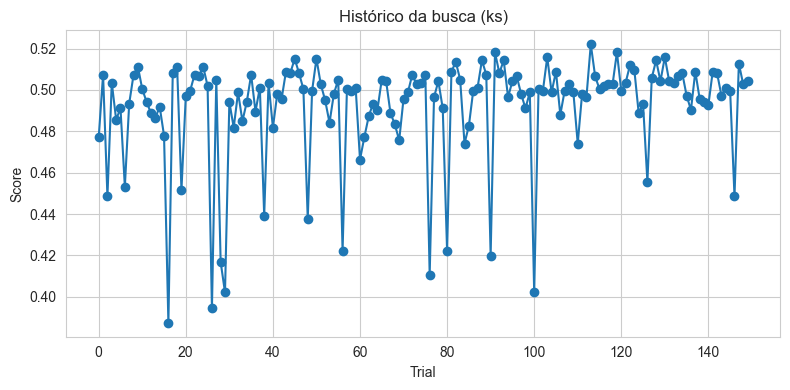

In [451]:
# Plotar a história da busca a partir dos resultados carregados
if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
    plot_df = loaded_trials_df.sort_values("number") if "number" in loaded_trials_df.columns else loaded_trials_df
    plt.figure(figsize=(8, 4))
    plt.plot(plot_df["value"].values, marker="o")
    plt.title(f"Histórico da busca ({scoring_metric})")
    plt.xlabel("Trial")
    plt.ylabel("Score")
    plt.tight_layout()
    plt.show()

## 6. Definir Melhores Params e Score de Busca

In [452]:
# Definir Melhores Parâmetros para Uso Posterior
if loaded_best_params is not None:
    best_params = loaded_best_params
    if loaded_trials_df is not None and "value" in loaded_trials_df.columns:
        best_score = (
            loaded_trials_df["value"].min()
            if direction == "minimize"
            else loaded_trials_df["value"].max()
        )
    else:
        best_score = study.best_value
    print(f"✅ Usando parâmetros carregados: {best_params}")
    print(f"✅ Melhor score carregado: {best_score:.6f}")
else:
    best_params = study.best_params
    best_score = study.best_value
    print(f"✅ Usando parâmetros da busca atual: {best_params}")
    print(f"✅ Melhor score da busca atual: {best_score:.6f}")

if isinstance(best_params.get("hidden_layer_sizes"), str):
    best_params["hidden_layer_sizes"] = eval(best_params["hidden_layer_sizes"])

✅ Usando parâmetros carregados: {'hidden_layer_sizes': [256, 128, 64], 'alpha': 0.6300114163922028, 'learning_rate_init': 0.004532500833130896, 'max_iter': 500, 'learning_rate': 'adaptive', 'solver': 'adam', 'batch_size': 256, 'activation': 'tanh', 'early_stopping': True, 'validation_fraction': 0.1, 'n_iter_no_change': 20}
✅ Melhor score carregado: 0.522042


## 7. Treinar Modelo Final e Salvar

In [453]:
best_model = MODEL_CLASS(**best_params, random_state=RANDOM_STATE_MODEL)
best_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","[256, 128, ...]"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'tanh'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.6300114163922028
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",256
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.004532500833130896
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [454]:
# Salvar o modelo treinado com os melhores hiperparâmetros 
MODELS_FOLDER = "models"
os.makedirs(MODELS_FOLDER, exist_ok=True)

model_path = os.path.join(MODELS_FOLDER, f'{MODEL_NAME.lower().replace(" ", "_")}_model.joblib')
dump(best_model, model_path)

print(f" Model saved to: {model_path}")

 Model saved to: models/mlp_model.joblib


## 8. Avaliação Final e Salvamento dos Resultados

In [455]:
# Carregar modelo (Opcional)
loaded_model = load(model_path)

In [456]:
print(f"=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - {MODEL_NAME} ===")

# Criar pastas se não existirem
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

# Avaliação completa do modelo
print("\nAvaliando:", MODEL_NAME)

# Usar datasets completos para avaliação final
X_train_eval = X_train_scaled
y_train_eval = y_train

X_val_eval = X_val_scaled
y_val_eval = y_val

X_test_eval = X_test_scaled
y_test_eval = y_test

# Avaliar modelo usando função do módulo
train_metrics, y_train_pred, y_train_scores = evaluate_model(
    best_model, X_train_eval, y_train_eval, device=device
)
val_metrics, y_val_pred, y_val_scores = evaluate_model(
    best_model, X_val_eval, y_val_eval, device=device
)
test_metrics, y_test_pred, y_test_scores = evaluate_model(
    best_model, X_test_eval, y_test_eval, device=device
)

=== AVALIAÇÃO E SALVAMENTO DOS RESULTADOS - MLP ===

Avaliando: MLP


### 8.1 Classification Report

In [457]:
print(classification_report(y_test_eval, y_test_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1294
           1       0.55      0.71      0.62       468

    accuracy                           0.77      1762
   macro avg       0.72      0.75      0.73      1762
weighted avg       0.79      0.77      0.78      1762



KS Statistic: 0.5185


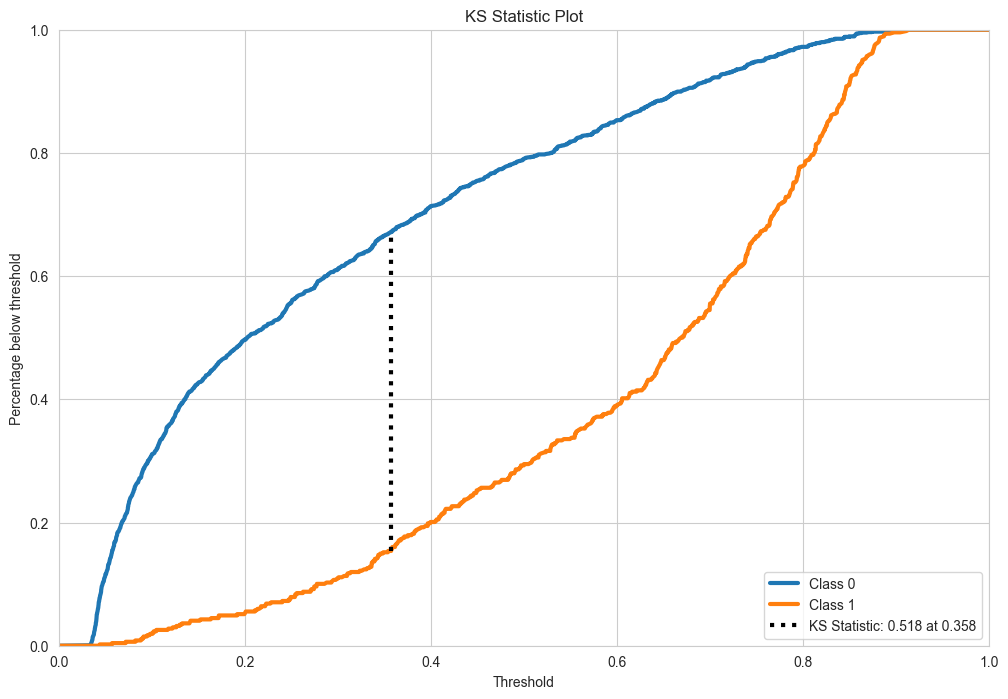

In [458]:
result = ks_test(y_test_eval, y_test_scores)
probas = result["probas"]
print(f"KS Statistic: {result['ks_stat']:.4f}")
ax = plot_ks_statistic(y_test_eval, probas)



### 8.2 Visualize Confusion Matrix

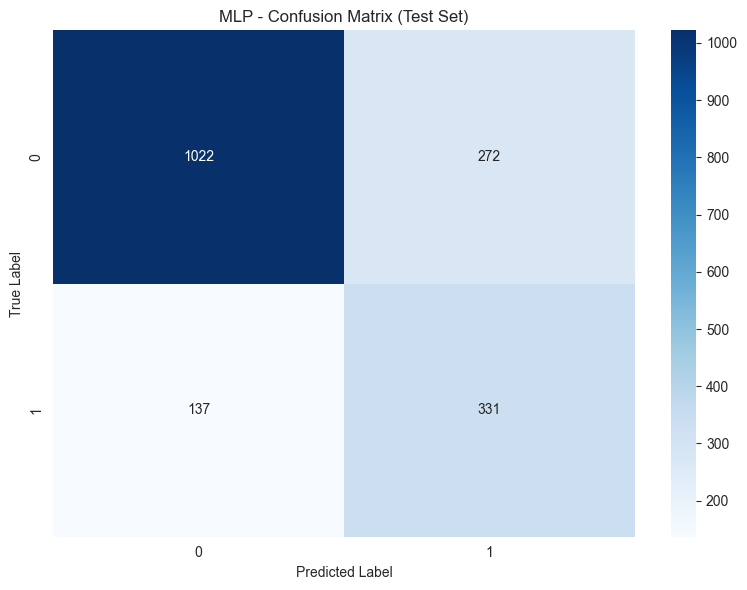

In [459]:
# Plot confusion matrix
cm = confusion_matrix(y_test_eval, y_test_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.title(f'{MODEL_NAME} - Confusion Matrix (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 8.3 Save Final Results

In [460]:
# Salvar resultados finais
RESULTS_FOLDER = "results"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

final_results = {
    "model_name": MODEL_NAME,
    "best_params": best_params,
    "best_score": best_score,
    "train_metrics": train_metrics,
    "val_metrics": val_metrics,
    "test_metrics": test_metrics,
}

final_path = os.path.join(RESULTS_FOLDER, f"{MODEL_NAME.lower()}_final_results.json")
with open(final_path, "w") as f:
    json.dump(final_results, f, indent=2, default=str)

# Mostrar resumo final
print(f"\n--- RESUMO FINAL {MODEL_NAME} ---")
print(f"Score da busca: {best_score:.6f}")
print(f"KS Statistic Teste: {test_metrics['ks_stat']:.4f}")
print(f"AUC-ROC Teste: {test_metrics['auroc']:.4f}")
print(f"F1-Score Teste: {test_metrics['f1']:.4f}")
print(f"Acurácia Teste: {test_metrics['accuracy']:.4f}")
print(f"Precisão Teste: {test_metrics['precision']:.4f}")
print(f"Recall Teste: {test_metrics['recall']:.4f}")


print(f"Resultados salvos em: {RESULTS_FOLDER}/")
print(f"Arquivo final: {final_path}")


--- RESUMO FINAL MLP ---
Score da busca: 0.522042
KS Statistic Teste: 0.5185
AUC-ROC Teste: 0.8366
F1-Score Teste: 0.6181
Acurácia Teste: 0.7679
Precisão Teste: 0.5489
Recall Teste: 0.7073
Resultados salvos em: results/
Arquivo final: results/mlp_final_results.json
